In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
data_dir = 'data/merge_data'  # Replace with the path to your main directory
img_height = 224
img_width = 224
batch_size = 32
epochs = 50  # Adjust as needed
validation_split = 0.2  # Percentage of data for validation

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=validation_split  
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',  # Assuming you have subdirectories for each class
    subset='training',
    shuffle=True,
    seed=42
)

Found 4060 images belonging to 12 classes.


In [5]:
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

Found 1012 images belonging to 12 classes.


In [6]:
class_labels = list(train_generator.class_indices.keys())
num_classes = len(class_labels)
class_counts = np.bincount(train_generator.classes)
print(f"Class labels: {class_labels}")
print(f"Number of classes: {num_classes}")
print(f"Class counts: {class_counts}")

Class labels: ['Acrylic', 'Blended', 'Cotton', 'Denim', 'Fleece', 'Fur', 'Leather', 'Other', 'Polyester', 'Silk', 'Velvet', 'Wool']
Number of classes: 12
Class counts: [ 80 640 640 596 202  80  80 484 640 237  80 301]


In [7]:
from collections import Counter

counter = Counter(train_generator.classes)
max_count = float(max(counter.values()))
class_weights = {class_id: max_count / count for class_id, count in counter.items()}
print(class_weights)

{np.int32(0): 8.0, np.int32(1): 1.0, np.int32(2): 1.0, np.int32(3): 1.0738255033557047, np.int32(4): 3.1683168316831685, np.int32(5): 8.0, np.int32(6): 8.0, np.int32(7): 1.322314049586777, np.int32(8): 1.0, np.int32(9): 2.70042194092827, np.int32(10): 8.0, np.int32(11): 2.12624584717608}


In [8]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3))

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
# x = Dense(512)(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [11]:
model = Model(inputs=base_model.input, outputs=predictions)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)  # Adjust learning rate as needed
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [13]:
early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # Monitor validation loss
    patience=10,            # Stop after 10 epochs of no improvement
    min_delta=0.001,        # Minimum change to be considered an improvement
    mode='min',             # We want the validation loss to minimize
    verbose=1,              # Print a message when it stops
    restore_best_weights=True # Restore model weights from the epoch with the best val_loss
)

class AccuracyThresholdCallback(tf.keras.callbacks.Callback):
    def __init__(self, accuracy_threshold=0.90, val_accuracy_threshold=0.90):
        super().__init__()
        self.accuracy_threshold = accuracy_threshold
        self.val_accuracy_threshold = val_accuracy_threshold
        print(f"Accuracy Threshold Callback initialized: Train Acc >= {accuracy_threshold*100}% OR Val Acc >= {val_accuracy_threshold*100}%")

    def on_epoch_end(self, epoch, logs=None):
        current_acc = logs.get('accuracy')
        current_val_acc = logs.get('val_accuracy')

        if current_acc is None or current_val_acc is None:
            print("Warning: 'accuracy' or 'val_accuracy' not found in logs. Cannot check thresholds.")
            return

        if current_acc >= self.accuracy_threshold or current_val_acc >= self.val_accuracy_threshold:
            print(f"\nEpoch {epoch+1}: Reached desired accuracy threshold!")
            print(f"  Train Acc: {current_acc:.4f}, Val Acc: {current_val_acc:.4f}")
            self.model.stop_training = True

In [14]:
my_callbacks = [
    AccuracyThresholdCallback(accuracy_threshold=0.90, val_accuracy_threshold=0.90),
    early_stopping_callback
]

Accuracy Threshold Callback initialized: Train Acc >= 90.0% OR Val Acc >= 90.0%


In [15]:
history = model.fit(
    train_generator,
#     steps_per_epoch=train_generator.samples // batch_size,
    epochs=epochs,
    validation_data=validation_generator,
#     validation_steps=validation_generator.samples // batch_size,  
    verbose=1,
    class_weight=class_weights,
    callbacks=my_callbacks
)

C:\Users\uzair\.conda\envs\ai-env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.2498 - loss: 3.9710 - val_accuracy: 0.4555 - val_loss: 1.5415
Epoch 2/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 204s 2s/step - accuracy: 0.4634 - loss: 2.4030 - val_accuracy: 0.4990 - val_loss: 1.4647
Epoch 3/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.5316 - loss: 2.0168 - val_accuracy: 0.5277 - val_loss: 1.3432
Epoch 4/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 186s 1s/step - accuracy: 0.5734 - loss: 1.8580 - val_accuracy: 0.5741 - val_loss: 1.2041
Epoch 5/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step - accuracy: 0.5917 - loss: 1.7711 - val_accuracy: 0.6067 - val_loss: 1.1754
Epoch 6/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 175s 1s/step - accuracy: 0.5971 - loss: 1.6664 - val_accuracy: 0.6196 - val_loss: 1.0998
Epoch 7/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.6067 - loss: 1.5663 - val_accuracy: 0.5978 - val_loss: 1.1628
Epoch 8/50
127/127 ━━━━━━━━━━━━━━━━━━━━ 171s 1s/step - accuracy: 0.6261 - loss: 1.5062 - val_accu

In [16]:
loss, accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // batch_size)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6313 - loss: 0.9275
Validation Loss: 0.7564
Validation Accuracy: 0.7177


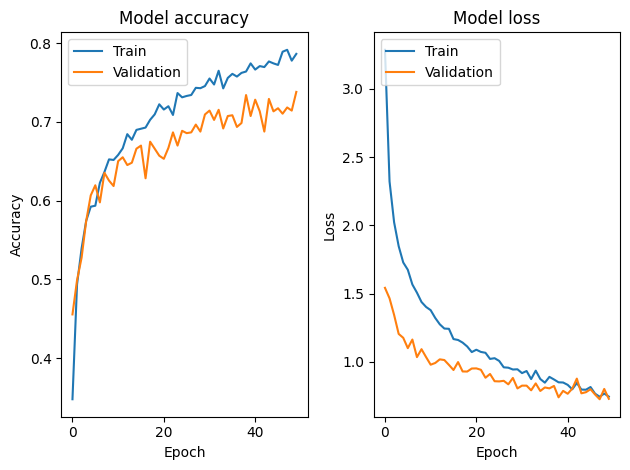

In [17]:
import matplotlib.pyplot as plt
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [18]:
model.save('models/whole_fabric_texture_model_2.h5')

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
model_path = "models/whole_fabric_texture_model_2.h5"
model_1 = tf.keras.models.load_model(model_path)

In [20]:
# --- 3. Make Predictions on the Validation Set ---
print("Making predictions on the validation set...")
# Predict probabilities for each class
y_pred_probs = model_1.predict(validation_generator, steps=validation_generator.samples // batch_size + 1)
# Convert probabilities to class labels (index of the highest probability)
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels from the generator
# The generator provides labels in the order it processes the data
y_true = validation_generator.classes

Making predictions on the validation set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step


In [21]:
class_names = list(validation_generator.class_indices.keys())
import numpy as np

# Get unique classes actually present
unique_classes = np.unique(y_true)

# Map those to names
class_names_filtered = [class_names[i] for i in unique_classes]

# Print report
print(classification_report(y_true, y_pred, target_names=class_names_filtered, labels=unique_classes, digits=4))

              precision    recall  f1-score   support

     Acrylic     0.8261    0.9500    0.8837        20
     Blended     0.6796    0.4375    0.5323       160
      Cotton     0.7083    0.6375    0.6711       160
       Denim     0.8535    0.9054    0.8787       148
      Fleece     0.8704    0.9400    0.9038        50
         Fur     1.0000    1.0000    1.0000        20
     Leather     0.5758    0.9500    0.7170        20
       Other     0.6807    0.6750    0.6778       120
   Polyester     0.7273    0.7500    0.7385       160
        Silk     0.6892    0.8644    0.7669        59
      Velvet     0.5152    0.8500    0.6415        20
        Wool     0.6552    0.7600    0.7037        75

    accuracy                         0.7283      1012
   macro avg     0.7318    0.8100    0.7596      1012
weighted avg     0.7293    0.7283    0.7215      1012



In [22]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_true, y_pred)
print(cm)


--- Confusion Matrix ---
[[ 19   0   0   0   0   0   0   1   0   0   0   0]
 [  0  70  30   2   1   0   3  14  20   3   2  15]
 [  0  16 102  13   3   0   1   6  11   4   1   3]
 [  0   3   0 134   0   0   3   3   1   0   0   4]
 [  1   0   0   0  47   0   0   1   0   0   1   0]
 [  0   0   0   0   0  20   0   0   0   0   0   0]
 [  0   0   0   0   0   0  19   0   0   0   1   0]
 [  0   6   1   4   1   0   2  81   7   9   4   5]
 [  2   4   9   2   2   0   3   3 120   7   5   3]
 [  0   0   0   0   0   0   0   2   4  51   2   0]
 [  0   0   0   0   0   0   0   2   1   0  17   0]
 [  1   4   2   2   0   0   2   6   1   0   0  57]]


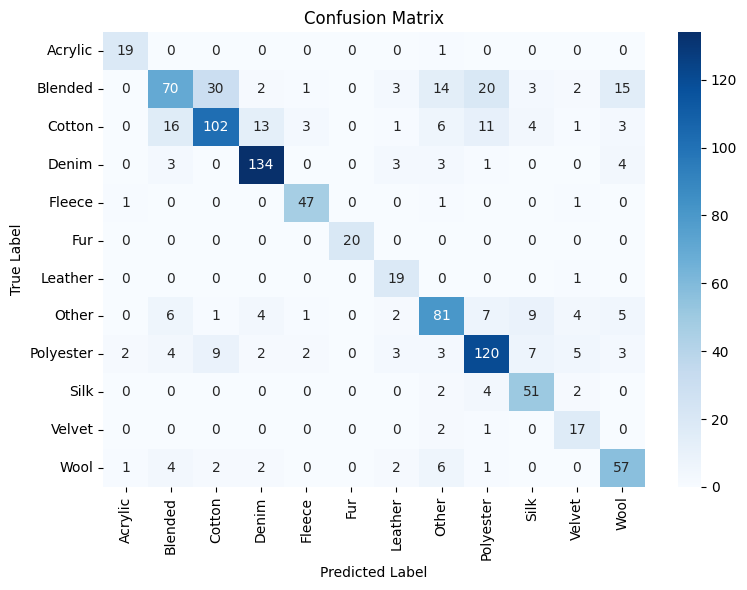

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
# Plotting the confusion matrix for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()